<a href="https://colab.research.google.com/github/sinhar1227/deep_learning/blob/main/Fine%20Tunning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import userdata

In [ ]:
READ_TOKEN=userdata.get("HF_TOKEN_READ")

In [ ]:
WRITE_TOKEN=userdata.get('HF_TOKEN_WRITE')

In [ ]:
# import os
# os.environ["HF_READ_TOKEN"] = userdata.get("HF_READ_TOKEN")
# os.environ["HF_WRITE_TOKEN"] = userdata.get("HF_WRITE_TOKEN")

In [ ]:
!pip install --upgrade huggingface_hub

In [ ]:
# from huggingface_hub import login
# login(READ_TOKEN)
# login(WRITE_TOKEN)

In [ ]:
from huggingface_hub import HfApi
# api = HfApi(token=WRITE_TOKEN)
api = HfApi()

In [ ]:
# api.create_repo(
#     repo_id="sunny199/sunnyrepo",  # full path
#     repo_type="model",                         # or just skip (default is model)
#     private=False                              # set True for private repo
# )

In [ ]:
# api.upload_file(
#     path_or_fileobj="/content/testfile/config.json",
#     path_in_repo="config.json",  # Where it goes in repo
#     repo_id="sunny199/sunnyrepo"  # Same as created above
# )

In [ ]:
# Get model info without downloading it
model_info = api.model_info(repo_id="bert-base-uncased")

In [ ]:
print("Model Card Metadata:", model_info.card_data)
print("Tags:", model_info.tags)
print("Commit SHA:", model_info.sha)
print("Last Modified:", model_info.last_modified)
print("Files:", [f.rfilename for f in model_info.siblings])
print("Model ID:", model_info.card_data.get('modelId', 'Not available'))
print("Likes:", model_info.likes)
print("Author/Namespace:", model_info.author)
print("Is Private:", model_info.private)
print("Downloads:", model_info.downloads)

In [ ]:
models = api.list_models(search="llama",limit=50)

In [ ]:
models

In [ ]:
for model in models:
    print(model.modelId, "-", model.downloads)

In [ ]:
models = api.list_models(search="embedding",limit=50)

In [ ]:
for model in models:
    print(model.modelId, "-", model.downloads)

In [ ]:
from huggingface_hub import list_repo_files
files = list_repo_files("google/flan-t5-base")
print(files)

In [ ]:
dataset = api.dataset_info("imdb")
print("Files:", [f.rfilename for f in dataset.siblings])

In [ ]:
from huggingface_hub import InferenceClient
client = InferenceClient(
    model="Qwen/Qwen2.5-7B-Instruct"
)
response = client.chat.completions.create(
    messages=[
        {"role": "user", "content": "Explain Hugging Face in simple words"}
    ],
    max_tokens=200
)
print(response.choices[0].message.content)

In [ ]:
# !pip install accelerate
# !pip install  bitsandbytes
!pip install langchain-huggingface
!pip install langchain_community

In [ ]:
from langchain_huggingface import ChatHuggingFace
from langchain_huggingface import HuggingFaceEndpoint

llm = HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-R1",
    task="text-generation",
    max_new_tokens=512,
    do_sample=False,
    repetition_penalty=1.03,
)
chat_model = ChatHuggingFace(llm=llm)
chat_model.invoke("hello how are you?")

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

template="""Question: {question}
give me a answer in detail manner and in step by step manner"""

prompt=PromptTemplate(template=template,input_variables=["question"])

llm_chain = (
        {"question": RunnablePassthrough()}
        | prompt
        | chat_model
        | StrOutputParser()
    )

question="who is a first president of INDIA?"

llm_chain.invoke({"question":question})

### 30-may-2026

read_token--> we can read anything from hf
write_token--> if we want to upload anything over the hf then we will use write

git--> github
hf-->hf hub(models, dataset)
hf repo
docker--> docker hub
ollama--> ollama hub

In [ ]:
import os
from huggingface_hub import HfApi
from google.colab import userdata

In [ ]:
api = HfApi(token=WRITE_TOKEN)

In [ ]:
api.create_repo(
    repo_id="sunny199/mytestingrepoformodel",  # full path
    repo_type="model",                         # or just skip (default is model)
    private=False                              # set True for private repo
)

In [ ]:
api.upload_file(
    path_or_fileobj="/content/test_file/dataset_info.json",
    path_in_repo="dataset_info.json",  # Where it goes in repo
    repo_id="sunny199/mytestingrepoformodel"  # Same as created above
)

## Notebook login

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
## Install datasets library

file system specification library

In [ ]:
!pip install -U datasets fsspec

| Config                |  Size | Text type | Use                |
| --------------------- | ----: | --------- | ------------------ |
| `wikitext-2-raw-v1`   | Small | Raw       | Learning/demo      |
| `wikitext-2-v1`       | Small | Processed | Benchmark/old NLP  |
| `wikitext-103-raw-v1` | Large | Raw       | Better LM training |
| `wikitext-103-v1`     | Large | Processed | Benchmark/old NLP  |


In [ ]:
from datasets import load_dataset

In [ ]:
pretrain_dataset = load_dataset(
    "Salesforce/wikitext",      # dataset repo / dataset name
    "wikitext-2-raw-v1",        # dataset variant / config
    split="train"               # train/validation/test part
)

In [ ]:
print(pretrain_dataset)

In [ ]:
for i in range(15):
    print(f"Row {i}:")
    print(pretrain_dataset[i])
    print("-" * 50)

In [ ]:
## example of instruction ft dataset or SFT dataset
sft_dataset = load_dataset(
    "tatsu-lab/alpaca",
    split="train"
)

In [ ]:
print(sft_dataset)

In [ ]:
for i in range(15):
    print(f"Row {i}:")
    print(sft_dataset[i])
    print("-" * 50)

In [ ]:
preference_dataset = load_dataset(
    "Anthropic/hh-rlhf",
    split="train"
)

In [ ]:
print(preference_dataset)

In [ ]:
for i in range(15):
    print(f"Row {i}:")
    print(preference_dataset[i])
    print("-" * 50)

In [ ]:
dataset = load_dataset("stanfordnlp/imdb")

In [ ]:
print(dataset)

In [ ]:
print(dataset["train"])

In [ ]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, even then it\'s not shot like some cheaply made porno. While my countrymen mind find it shocking, in reality sex and nudity are a major staple in Swedish cinema. Even Ingmar Bergman, arguably their answer to good old boy John Ford, had sex scenes in his films.<br /><br />I do commend the filmmakers for the fact that any sex shown in the film is shown for artistic purposes rather than just to shock people and make money to be shown in pornographic theaters in America. I AM CURIOUS-YELLOW is a good film for anyone wanting to study the meat and potatoes (no pun intended) of Swedish cinema. But really, this film doesn\'t have much of a plot.', 'label': 0}

In [ ]:
print(dataset["train"].features)
print(dataset["train"].column_names)
print(dataset["train"].features["label"].names)
print(dataset["train"].num_rows)
print(dataset["train"].num_columns)
print(dataset["train"].shape)

In [ ]:
shuffled = dataset["train"].shuffle()

In [ ]:
shuffled

In [ ]:
shuffled = dataset["train"].shuffle(seed=42)

In [ ]:
subset_train = dataset["train"].shuffle().select(range(5000))

In [ ]:
subset_train

In [ ]:
dataset["train"]

In [ ]:
short_reviews = dataset["train"].filter(lambda x: len(x["text"]) < 100)

In [ ]:
short_reviews

In [ ]:
short_positive = dataset["train"].filter(lambda x: x["label"] == 1 and len(x["text"]) < 200)

In [ ]:
short_positive

In [ ]:
def add_word_count(example):
    example["word_count"] = len(example["text"].split())
    return example

In [ ]:
dataset = dataset.map(add_word_count)

In [ ]:
dataset

In [ ]:
print(dataset["train"][0]["word_count"])

streaming=True Parameter

Normally, Hugging Face datasets are downloaded completely to disk before being used (especially for large datasets, this can be slow/heavy).

When streaming=True:

The dataset is not downloaded in full

Data is streamed sample-by-sample on-the-fly

Useful for huge datasets that can’t fit into memory (like c4, the_pile, openwebtext)

You get a generator-style iterable dataset, not an in-memory list

Dataset: openwebtext

Size: ~8.13 million documents

Total tokens: ~40+ billion tokens

Size on disk: ~38 GB

In [ ]:
big_data = load_dataset(
    "Skylion007/openwebtext",
    streaming=True
)

### metadata (80 shards/files)

In [ ]:
big_data

In [ ]:
for i, row in enumerate(big_data["train"]):
    print(row)
    print("-" * 50)

    if i == 14:
        break

In [ ]:
print(row["text"][:500])

In [ ]:
for item in big_data["train"].take(5):
    print(item)

## Custom dataset

In [ ]:
from datasets import Dataset

In [ ]:
import pandas as pd
data = {
    "text": [
        "I love this product! Works great ",
        "Terrible experience, I want a refund.",
        "Fast delivery and excellent packaging.",
        "Worst app I’ve ever used. Crashed in 1 minute.",
        "Super helpful support team, thanks a lot!",
        "Nothing worked. Waste of time."
    ],
    "label": [1, 0, 1, 0, 1, 0]  # 1 = Positive, 0 = Negative
}

In [ ]:
df = pd.DataFrame(data)

In [ ]:
df

In [ ]:
dataset = Dataset.from_pandas(df)

In [ ]:
dataset

In [ ]:
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN_WRITE")

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '6570208f15709277ede7d985', 'name': 'sunny199', 'fullname': 'sunny savita', 'email': 'engsunny3365@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1780272000, 'isPro': False, 'avatarUrl': '/avatars/dfb8ae1e662d7a9995b3059127282976.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'testinglivewrite', 'role': 'write', 'createdAt': '2025-06-24T19:33:21.245Z'}}}

In [ ]:
dataset.push_to_hub("sunny199/mycustomdatalivebootcamp")

In [ ]:
from datasets import Dataset

data = {
    "instruction": [
        "Translate English to Hindi",
        "Summarize the text",
        "Explain Machine Learning"
    ],
    "input": [
        "I love India",
        "Artificial Intelligence is transforming industries.",
        ""
    ],
    "output": [
        "मुझे भारत पसंद है",
        "AI industries ko transform kar raha hai.",
        "Machine Learning is a subset of AI."
    ]
}

dataset = Dataset.from_dict(data)

In [ ]:
dataset

### Tokenization

"I love AI"

["I", "love", "AI"]

[40, 1842, 9552]



| Model   | Tokenizer Type   |
| ------- | ---------------- |
| BERT    | WordPiece        |
| GPT-2   | BPE              |
| Llama   | SentencePiece    |
| T5      | SentencePiece    |
| Qwen    | custom tokenizer |
| Mistral | SentencePiece    |


In [ ]:
!pip install transformers

In [ ]:
from transformers import AutoTokenizer

In [ ]:
# from transformers import AutoModel

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [ ]:
text = "I love AI"

In [ ]:
output = tokenizer(text)

In [ ]:
print(output)

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(output["input_ids"])

'input_ids': [101, 146, 1567, 19016, 102]

In [ ]:
print(tokens)

In [ ]:
output = tokenizer("I love AI", "I love ML")

In [ ]:
print(output)

In [ ]:
tokenizers = [
    "bert-base-uncased",
    "bert-base-cased",
    "roberta-base",
    "distilbert-base-uncased",
    "gpt2",
    "facebook/opt-125m",
    "google/flan-t5-small",
    "t5-small",
    "microsoft/deberta-v3-base",
    "xlnet-base-cased",
    "albert-base-v2",
    "sentence-transformers/all-MiniLM-L6-v2",
    "meta-llama/Llama-2-7b-hf",
    "mistralai/Mistral-7B-v0.1",
    "Qwen/Qwen2.5-0.5B",
    "google/gemma-2-2b",
]

In [ ]:
for model_name in tokenizers:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print(model_name, "->", tokenizer.__class__.__name__)

In [ ]:
hindi_tokenizer = AutoTokenizer.from_pretrained("ai4bharat/indic-bert")

In [ ]:
tokens=hindi_tokenizer.tokenize("मुझे एआई पसंद है।")

In [ ]:
tokens

1. input_ids:

These are the IDs of the tokens from the model’s vocabulary.

The sentence "Hello, how are you?" gets tokenized as:

[CLS] Hello , how are you ? [SEP]

Which corresponds to:

[101, 7592, 1010, 2129, 2024, 2017, 1029, 102]

2. token_type_ids:

These are used in tasks like Next Sentence Prediction.

0 means it's part of the first sentence

If there was a second sentence, it would have 1s

Since your input is just a single sentence, all values are 0.

3. attention_mask:

Tells the model which tokens are real and which are padding.

1 means the token is real (not padding)

0 means it’s padding (none here)

What does return_tensors="pt" do?

It returns everything as PyTorch tensors (pt = PyTorch).

If you use return_tensors="tf", you'll get TensorFlow tensors.

BPE-
wordpiece-google
sentence_piece-google


# Custom Tokenizer Training Pipeline

```text
Raw Text Corpus
      ↓
Train BPE Tokenizer
      ↓
Save tokenizer.json
      ↓
Convert to Hugging Face Tokenizer
      ↓
Save my_tokenizer_hf Folder
```

BPE = Byte Pair Encoding.

Simple idea:

Frequently appearing characters/subwords ko merge karke vocabulary banata hai.

Example:

t + r → tr

tr + a → tra

tra + n → tran

...

transformers

In [ ]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [ ]:
corpus = ["I love transformers!",
          "Tokenizers are amazing.",
          "Build your own.\n"]

In [ ]:
corpus


In [ ]:
tokenizer = Tokenizer(models.BPE())

In [ ]:
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

In [ ]:
trainer = trainers.BpeTrainer(vocab_size=100)

In [ ]:
tokenizer.train_from_iterator(corpus, trainer)

In [ ]:
tokenizer.save("custom-tokenizer.json")

In [ ]:
from transformers import PreTrainedTokenizerFast

In [ ]:
hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file="/content/custom-tokenizer.json",
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]"
)

In [ ]:
hf_tokenizer.save_pretrained("my_tokenizer_hf")

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("my_tokenizer_hf")

In [ ]:
text = "I love transformers!"

output = tokenizer(text)

print(output)

| Feature                       | BPE (Byte Pair Encoding)                                 | WordPiece                                             | SentencePiece                             |
| ----------------------------- | -------------------------------------------------------- | ----------------------------------------------------- | ----------------------------------------- |
| **Developed By**              | Originally for compression, later used in GPT models     | Google (BERT)                                         | Google                                    |
| **Used In**                   | GPT-2, RoBERTa, LLaMA (variants)                         | BERT, DistilBERT                                      | T5, ALBERT, mT5, LLaMA tokenizer training |
| **Training Strategy**         | Merge most frequent character pairs repeatedly           | Choose merge that maximizes language model likelihood | Learns subwords directly from raw text    |
| **Input Requirement**         | Requires pre-tokenized text (spaces already split words) | Requires pre-tokenized text                           | Works directly on raw text                |
| **Space Handling**            | Spaces are separators                                    | Spaces are separators                                 | Treats space as a normal symbol (`▁`)     |
| **Merge Selection**           | Frequency-based                                          | Probability/Likelihood-based                          | Unigram Language Model or BPE             |
| **Vocabulary Creation**       | Frequent character pair merges                           | Best likelihood improvement merges                    | Probabilistic subword selection           |
| **Unknown Words**             | Split into smaller subwords                              | Split into smaller subwords                           | Split into smaller subwords               |
| **Language Independence**     | Moderate                                                 | Moderate                                              | Very high                                 |
| **Best For**                  | Simple and fast tokenization                             | Better linguistic segmentation                        | Multilingual and production systems       |
| **Training Complexity**       | Low                                                      | Medium                                                | Higher                                    |
| **Token Example ("playing")** | play + ing                                               | play + ##ing                                          | ▁play + ing                               |
| **Special Marker**            | None                                                     | `##` for continuation                                 | `▁` for word boundary                     |


### Now load the models

In [ ]:
from transformers import AutoTokenizer, AutoModel

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [ ]:
inputs = tokenizer("Hello, how are you?", return_tensors="pt")

In [ ]:
inputs

In [ ]:
## base and raw model of the bert
## not only the bert you can download any model
## it is downloading a model in your  volatile memory(RAM)
model = AutoModel.from_pretrained("bert-base-uncased")

In [ ]:
model

In [ ]:
# Total encoder layers
print(len(model.encoder.layer))

In [ ]:
# First layer ka attention
print(model.encoder.layer[0].attention)

In [ ]:
for i, layer in enumerate(model.encoder.layer):
    print(f"Layer {i}:")
    print(layer.attention)
    print("-" * 50)

In [ ]:
for i, layer in enumerate(model.encoder.layer):
    print(f"Layer {i}")
    print("Query:", layer.attention.self.query)
    print("Key:  ", layer.attention.self.key)
    print("Value:", layer.attention.self.value)
    print()

In [ ]:
print("Hidden size:", model.config.hidden_size)
print("Number of layers:", model.config.num_hidden_layers)
print("Attention heads:", model.config.num_attention_heads)
print("Intermediate size:", model.config.intermediate_size)

Embedding(30522, 768)

BERT vocabulary size = 30,522 tokens

Each token vector size = 768

"hello" → 768-dimensional vector

position_embeddings

Embedding(512, 768)

BERT handle maximum 512 token positions.

Meaning:

Token position 1 → 768 vector

Token position 2 → 768 vector

...

Token position 512 → 768 vector

BertEncoder

(layer): ModuleList((0-11): 12 x BertLayer)

Each layer ka structure:

Self-Attention
   ↓
Add + Norm
   ↓
Feed Forward Network
   ↓
Add + Norm

Self-Attention
query: Linear(768 → 768)
key:   Linear(768 → 768)
value: Linear(768 → 768)

Feed Forward Network

dense: 768 → 3072

GELU

dense: 3072 → 768

LayerNorm + Dropout

LayerNorm((768,))

Dropout(0.1)

LayerNorm

stable Training.

Dropout

reduce Overfitting

Pooler
(pooler): BertPooler(
  dense: 768 → 768
  activation: Tanh
)

Pooler usually take [CLS] token and transform that

Mostly classification tasks me.

In [ ]:
inputs

In [ ]:
import torch
with torch.no_grad():
    outputs = model(**inputs)

In [ ]:
print(outputs)

In [ ]:
[[[-0.5926,  0.0308,  0.0145,  ...,  0.0067,  0.3493,  0.8801],
         [ 0.1507,  0.0496,  0.2720,  ...,  0.2301,  0.5543, -0.0939],
         [-0.2256, -0.2712, -0.1375,  ..., -0.1161,  0.3052,  0.2588],
         ...,
         [ 0.0476, -0.2572,  0.1349,  ..., -0.0117,  0.2032, -0.3086],
         [-0.3472, -0.3266, -0.1795,  ...,  0.1174,  0.1640,  0.1084],
         [ 0.4908,  0.0212, -0.5450,  ...,  0.3898, -0.8815, -0.1950]]]

In [ ]:
print(outputs.last_hidden_state.shape)

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

for token, vector in zip(tokens, outputs.last_hidden_state[0]):
    print(token, vector[:5])

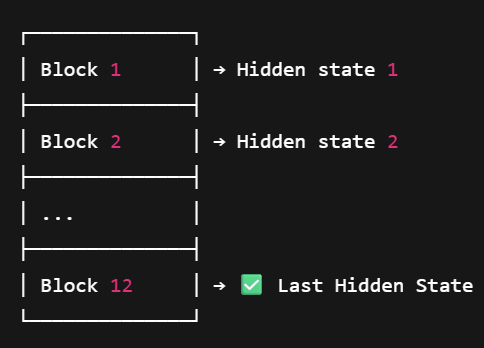

[Multi-head Attention] → [Add + Norm] → [Feedforward] → [Add + Norm]


## Example of AutoModelClass with Different heads

| Task                        | Class Name                                          | Description                                          |
| --------------------------- | --------------------------------------------------- | ---------------------------------------------------- |
| Base Model               | `AutoModel`                                         | Just embeddings (no head), for feature extraction    |
| Masked LM                | `AutoModelForMaskedLM`                              | For BERT-style `[MASK]` prediction                   |
| Sequence Classification | `AutoModelForSequenceClassification`                | For sentence-level tasks like sentiment, spam        |
| Token Classification     | `AutoModelForTokenClassification`                   | For NER, POS tagging (token-level labels)            |
| Multiple Choice          | `AutoModelForMultipleChoice`                        | For MCQ tasks (e.g., SWAG dataset)                   |
| Next Sentence Prediction | `AutoModelForNextSentencePrediction`                | For NSP (mainly BERT pretraining)                    |
| Causal LM (Text Gen)     | `AutoModelForCausalLM`                              | For GPT-style models (left-to-right text generation) |
| Seq2Seq LM               | `AutoModelForSeq2SeqLM`                             | For translation, summarization (T5, BART)            |
| Question Answering       | `AutoModelForQuestionAnswering`                     | For extractive QA (SQuAD-style)                      |
| Vision Tasks            | `AutoModelForImageClassification`, etc.             | For image classification (e.g., ViT)                 |
| Audio Tasks              | `AutoModelForAudioClassification`, etc.             | For Wav2Vec, Whisper, etc.                           |
| Conditional Generation   | `AutoModelForConditionalGeneration`                 | For T5/BART-style seq2seq tasks                      |
| Zero-shot Tasks          | `AutoModelForZeroShotClassification` (via pipeline) | For inference without fine-tuning                    |
| Contrastive Learning     | `AutoModelForContrastiveLearning`                   | For embeddings comparison tasks                      |


In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

text = "Hello, how are [MASK]?"

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

mask_index = torch.where(inputs["input_ids"][0] == tokenizer.mask_token_id)[0]
predicted_id = outputs.logits[0, mask_index].argmax(dim=-1)

print(tokenizer.decode(predicted_id))

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

prompt = "Explain reinforcement learning in simple words."

inputs = tokenizer(prompt, return_tensors="pt")

outputs = model.generate(
    **inputs,
    max_new_tokens=80,
    do_sample=True,
    temperature=0.7
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

In [ ]:
print(model)

In [ ]:
print(model.config)
print("Layers:", model.config.num_hidden_layers)
print("Hidden size:", model.config.hidden_size)
print("Attention heads:", model.config.num_attention_heads)
print("Vocab size:", model.config.vocab_size)

In [ ]:
print(len(model.model.layers))

In [ ]:
print(model.model.layers[0].self_attn)

In [ ]:
for i, layer in enumerate(model.model.layers):
    print(f"Layer {i}")
    print(layer.self_attn)
    print("-" * 50)

In [ ]:
text = "Hello, how are you?"
inputs = tokenizer(text, return_tensors="pt")

print(inputs)
print(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))

In [ ]:
import torch

with torch.no_grad():
    outputs = model(**inputs)

print(outputs.keys())

[batch_size, sequence_length, vocab_size]

In [ ]:
print(outputs.logits.shape)

In [ ]:
generated_ids = model.generate(
    **inputs,
    max_new_tokens=50
)

print(tokenizer.decode(generated_ids[0], skip_special_tokens=True))

In [ ]:
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

print(len(outputs.hidden_states))
print(outputs.hidden_states[-1].shape)

local_dir_use_symlinks=True
→ Creates shortcuts that point to the original files.

local_dir_use_symlinks=False
→ Copies the actual files into the target folder.

In [ ]:
from huggingface_hub import snapshot_download

In [ ]:
snapshot_download(
    repo_id="bert-base-uncased",
    local_dir="/content/download-model-on-disk",   # where to download
    local_dir_use_symlinks=False  # to copy instead of symlinking
)

In [ ]:
from transformers import AutoTokenizer, AutoModel

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("/content/download-model-on-disk")

In [ ]:
tokenizer

In [ ]:
model = AutoModel.from_pretrained("/content/download-model-on-disk")

In [ ]:
model

In [ ]:
!pip install -U sentence-transformers

In [ ]:
sentence1="I love AI"
sentence2="I love car"

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [ ]:
embedding1 = model.encode(sentence1, convert_to_tensor=True)

In [ ]:
embedding1

In [ ]:
len(embedding1)

In [ ]:
embedding2 = model.encode(sentence2, convert_to_tensor=True)

In [ ]:
embedding2

In [ ]:
## unsqueeze(0) converts a single embedding vector [768] into a one-sample batch [1, 768].

In [ ]:
import torch.nn.functional as F

similarity = F.cosine_similarity(
    embedding1.unsqueeze(0),
    embedding2.unsqueeze(0)
)

print(similarity.item())